In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from ase.io.trajectory import Trajectory
from flonacomldft.collective_variables import get_collective_variables
import numpy as np
import torch
import pandas as pd

In [2]:
path_database = '/mnt/home/amolina/ceph/adaptive-flow-mc/database/andersen/'
md_files = ['trajectories/27037382_is0_andersen.traj',  'trajectories/27037385_is1_andersen.traj']

trajs = {i: Trajectory(path_database + md_files[i])[200:] for i in range(len(md_files))}

In [3]:
len(trajs[0]), len(trajs[1])

(9801, 9801)

In [4]:
temperature = {i: np.array([molecule.get_temperature() for molecule in trajs[i]]) for i in trajs.keys()}

In [5]:
from flonacomldft.utils.io_utils import save_ase_molecules_as_traj

In [6]:
trajs = {i: trajs[i][::10] for i in range(len(md_files))}

In [9]:
len(trajs[0][:50])


50

In [10]:
len(trajs[1][:50])

50

In [ ]:
save_ase_molecules_as_traj(trajs[0][:100], 'is0_md.traj')
save_ase_molecules_as_traj(trajs[1][:100], 'is1_md.traj')

In [23]:
import matplotlib.pyplot as plt

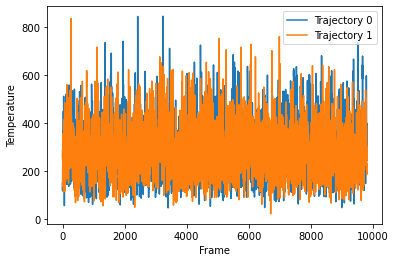

In [26]:
plt.plot(temperature[0], label='Trajectory 0')
plt.plot(temperature[1], label='Trajectory 1')
plt.xlabel('Frame')
plt.ylabel('Temperature')
plt.legend()
plt.show()


In [35]:
u = {i: np.array([molecule.get_potential_energy() for molecule in trajs[i]]) for i in trajs.keys()}

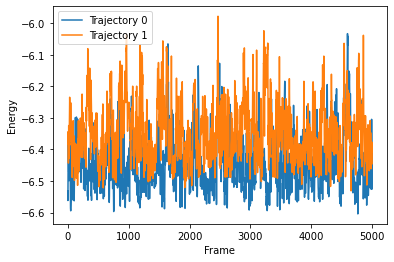

In [36]:
plt.plot(u[0][100:5100], label='Trajectory 0')
plt.plot(u[1][100:5100], label='Trajectory 1')
plt.xlabel('Frame')
plt.ylabel('Energy')
plt.legend()
plt.show()


In [6]:
cv = {i: np.stack([get_collective_variables(molecule) for molecule in trajs[i][:5]]) for i in trajs.keys()}

In [12]:
import torch
from flonacomldft.internal_coordinates import Coordinates_mapping

In [13]:
from flonacomldft.internal_coordinates import save_internal_coordinates_to_csv

In [14]:
coord_mapping = Coordinates_mapping()
dim = 12
isomer_label = 0

In [15]:
zmats = coord_mapping.get_internal_from_trajectory(trajectory=trajs[isomer_label][:5], 
                                            isomer=isomer_label,
                                            temperature=350, 
                                            add_potential_energy=True,
                                            add_cvs=True,)

In [28]:
'27037382_is0_andersen.traj'.split('/')[-1].split('.')[0]+ '_zmats' + '.csv'

'27037382_is0_andersen_zmats.csv'

In [17]:
from flonacomldft.utils.silver_isomers_utils import get_construction_table
construction_table = get_construction_table()
save_internal_coordinates_to_csv(zmats, 
                                construction_table=construction_table, 
                                filename='internal_coordinates_is{:d}.csv'.format(isomer_label), 
                                path=path_database + '/internal_coordinates')

In [19]:
coord_xs, logdetjac_xs, energies_xs = coord_mapping.get_real_centered_from_internal(zmats[:, :dim], 
                                                    isomer=isomer_label, 
                                                    temperature=350,
                                                    energies=zmats[:, dim],
                                                    logdetjacs=zmats[:, dim+2])

In [20]:
xs = torch.cat([coord_xs, 
                energies_xs.reshape(-1, 1),
                torch.ones(coord_xs.shape[0]).reshape(-1, 1)*isomer_label,
                logdetjac_xs.reshape(-1, 1),
                zmats[:, -2:]], dim=1)

In [22]:
columns = ['rc{:d}' for i in range(dim)]
save_internal_coordinates_to_csv( xs, 
                                columns=columns, 
                                filename='real_centered_coordinates_is{:d}.csv'.format(isomer_label), 
                                path=path_database + '/internal_coordinates')

In [29]:
from flonacomldft.utils.io_utils import get_path, load_pickle_file
import torch

In [30]:
flow_models = [ load_pickle_file('dict_flow_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/')['model'] for i in range(2)]
mlp_model = [load_pickle_file('dict_mlp_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/')['model'] for i in range(2)]

In [31]:
from flonacomldft.models.mixture import Mixture

flow_model = Mixture(flow_models, torch.tensor([0.5, 0.5]))

In [32]:
n_chains = 10
n_steps = 20
xs_init = flow_model.sample(n_chains)
us_init = mlp_model[0](xs_init)
isomers_init = torch.zeros(n_chains, 1)

init = torch.cat([xs_init, us_init, isomers_init], dim=1)

In [5]:
from flonacomldft.sampling import run_metropolis

In [34]:
mh = run_metropolis(model = flow_model, 
                init = init, 
                n_chains = n_chains,
                n_steps = n_steps,
                id_run = 'N/A', 
                energy_type = 'mlp', 
                temperature = 350,
                mixture = True,
                mlp_models = mlp_model,
                frac_computed = 0.2,
                dim = 12,
                update_weights = True,
                scheduler_weights = 5,
                alpha = 0.5,
                return_ratios = False,
                return_proposals = True,
                with_tqdm = False,
                folder_name = None,
                )

Running Metropolis-Hastings
Number of chains: 10
Number of steps: 20
Temperature: 350K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True
Step 	 Acc Rate 	 Population
0 	 0.800 		 0.300
1 	 0.500 		 0.200
2 	 0.500 		 0.100
3 	 0.300 		 0.000
4 	 0.300 		 0.000
5 	 0.400 		 0.000
6 	 0.300 		 0.000
7 	 0.100 		 0.000
8 	 0.200 		 0.000
9 	 0.300 		 0.000
10 	 0.100 		 0.000
11 	 0.200 		 0.000
12 	 0.400 		 0.000
13 	 0.400 		 0.000
14 	 0.300 		 0.000
15 	 0.200 		 0.000
16 	 0.200 		 0.000
17 	 0.300 		 0.000
18 	 0.400 		 0.000
19 	 0.100 		 0.000


In [35]:
from flonacomldft.utils.io_utils import load_csv_file
from flonacomldft.train_flow_from_data import train_flow
from flonacomldft.train_mlp_from_data import train_mlp

In [36]:
#flow_train = [load_csv_file('is'+str(i)+'_flow_train.csv', get_path() + '/andersen/datasets')[:, :14]
#              for i in range(2)]
#flow_test = [load_csv_file('is'+str(i)+'_flow_test.csv', get_path() + '/andersen/datasets')[:, :14]
#                for i in range(2)]

from flonacomldft.utils.data_processing import load_datasets

flow_train = []
flow_test = []

isomer_labels = [0, 1]

for isomer_label in isomer_labels:
    
    dataset = load_datasets('andersen', isomer_label, name='flow', real_centered=True)
    flow_train.append(dataset['train'].clone())
    flow_test.append(dataset['test'].clone())

    del dataset

In [37]:
dict_flow_models = [ load_pickle_file('dict_flow_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/') for i in range(2)]
dict_mlp_models = [load_pickle_file('dict_mlp_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/') for i in range(2)]

In [38]:
n_runs = 5
n_chains = 10
n_steps = 5

flow_hyperparams = {'n_iter': 10,
    'lr': 1e-3,
    'bs': 200,
    'use_scheduler': True,
    'step_scheduler': 10,
    'save_splits': 1,
    'grad_clip': 1e4,
    }

mlp_hyperparams = {'n_iter': 10,
    'lr': 1e-3,
    'bs': 200,
    'use_scheduler': True,
    'step_schedule': 100,
    'save_splits': 1,
    }

In [39]:
from flonacomldft.full_adaptive_sampling import run_adaptive_sampling

In [40]:
adaptive_sampling = run_adaptive_sampling(mcmc_init=init, 
                n_chains=n_chains,
                n_steps=n_steps,
                n_runs=n_runs,
                flow_init_train=flow_train,
                flow_init_test=flow_test,
                dict_flows_init=dict_flow_models,
                flow_hyperparams=[flow_hyperparams, flow_hyperparams],
                energy_type='emt-mlp',
                temperature=350,
                mixture=True,
                dim=12,
                dict_mlps_init=dict_mlp_models,
                mlp_init_train=flow_train,
                mlp_init_test=flow_test,
                mlp_hyperparams=[mlp_hyperparams, mlp_hyperparams],
                train_mlp_models=True,
                frac_computed=0.2,
                init_weights=None,
                update_weights=True,
                scheduler_weights=10,
                n_samples_train_flow=None,
                folder_name='',
                alpha=0.5,
                device='cpu',
)

Adaptive sampling
Number of runs:  5
Number of chains:  10
Number of steps:  5
Temperature:  350
Energy type:  emt-mlp
Mixture model:  True
Isomer labels:  [0, 1]
Flow train dataset shapes:  [[4000, 14], [4000, 14]]
Flow test dataset shapes:  [[1000, 14], [1000, 14]]
tensor([4000, 4000])
tensor([200, 200])
tensor([20, 20], dtype=torch.int32)
MLP train dataset shapes:  [[4000, 14], [4000, 14]]
MLP test dataset shapes:  [[1000, 14], [1000, 14]]
Initial weights:  [0.5, 0.5]
Number of samples for training flows:  [4000, 4000]
Current weights:  [0.5, 0.5]
Running Metropolis-Hastings
Number of chains: 10
Number of steps: 5
Temperature: 350K
Energy Type: emt-mlp
Mixture model
Use Neural Predictor: True
Use EMT Calculator: True
Mixture Model: True
Step 	 Acc Rate 	 Population
0 	 0.600 		 0.200
1 	 0.500 		 0.200
2 	 0.300 		 0.000
3 	 0.500 		 0.000
4 	 0.200 		 0.000
Isomer:  0
Flow train dataset shape:  [4000, 14]
Flow chains dataset shape:  [46, 14]
Flow train dataset shape:  [4046, 14]
Fl

In [41]:
from flonacomldft.train_flow_from_data import train_flow

In [42]:
flow = train_flow(
        model=flow_models[0],
        train=flow_train[0],
        n_iter=100,
        lr=1e-3,
        bs=200,
        use_scheduler=True,
        step_scheduler=10,
        save_splits=1,
        grad_clip=1e4,
        with_tqdm=False,
        n_partial_loss=10,
        dim=12
)

Epoch 		 Lr 		 Loss 		 Grad norm
0.0e+00 	 1.00e-03 	 -9.71e+00 	 2e+01
1.0e+01 	 5.00e-04 	 -1.09e+01 	 7e+00
2.0e+01 	 2.50e-04 	 -1.11e+01 	 4e+00
3.0e+01 	 1.25e-04 	 -1.11e+01 	 4e+00
4.0e+01 	 6.25e-05 	 -1.12e+01 	 4e+00
5.0e+01 	 3.13e-05 	 -1.12e+01 	 4e+00
6.0e+01 	 1.56e-05 	 -1.12e+01 	 4e+00
7.0e+01 	 7.81e-06 	 -1.12e+01 	 4e+00
8.0e+01 	 3.91e-06 	 -1.12e+01 	 4e+00
9.0e+01 	 1.95e-06 	 -1.12e+01 	 4e+00


In [47]:
flow.keys()

dict_keys(['model', 'losses', 'grad_norms', 'time_step'])

In [44]:
import copy
import time
import torch
import tqdm
from torch.nn.utils import clip_grad_norm_

def train_mlp(
    model,
    train,
    test,
    n_iter,
    lr,
    bs,
    use_scheduler=False,
    step_scheduler=10,
    save_splits=1,
    grad_clip=1e4,
    with_tqdm=False,
    n_partial_loss=10,
    dim=12,  
    ):
    
    def loss_func(x, y):
        return ((model(x).squeeze() - y)**2).mean()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 
                                                    step_size=step_scheduler, 
                                                    gamma=0.5)
        
    if save_splits > 1:
        models = [copy.deepcopy(model)]

    if with_tqdm:
        pbar = tqdm.tqdm(range(n_iter))
    else:
        pbar = range(n_iter)
        print('Epoch \t\t Lr \t\t Train Loss \t Test Loss \t Grad norm')


    train_losses = []
    test_losses = []
    grad_norms = []
    time_step = []

    x_train, y_train = train[:, :dim], train[:, dim]
    x_test, y_test = test[:, :dim], test[:, dim]

    permutation = torch.randperm(x_train.size()[0])

    for t in pbar:

        for k in range(0, x_train.size()[0], bs):

            indices = permutation[k:k+bs]
            x_batch, y_batch = x_train[indices].detach(), y_train[indices].detach()

            optimizer.zero_grad()
            loss = loss_func(x_batch, y_batch)
            
            if torch.isinf(loss).any():
                print('Stopped because loss became of inf!')
                return {'model': model, 
                        'train_loss': train_losses, 
                        'test_losses': test_losses}

            loss.backward()
            clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()

            train_losses.append(loss.item())
            test_losses.append(loss_func(x_test, y_test).item())

            time_step.append(time.time())

        if t % (n_iter / 100) == 0:
            total_norm = 0
            for p in model.parameters():
                param_norm = p.grad.detach().data.norm(2)
                total_norm += param_norm.item() ** 2
            total_norm = total_norm**0.5
            grad_norms.append(total_norm)

        if use_scheduler:
            scheduler.step()

        if with_tqdm == False:

            if t % (n_iter // n_partial_loss) == 0:

                for param_group in optimizer.param_groups:
                    lr_ = param_group['lr']

                print('{:0.1e} \t {:0.2e} \t {:3.2e} \t {:3.2e} \t {:0.1e}'.format(t, lr_, train_losses[-1], test_losses[-1], grad_norms[-1]))

        else:

            pbar.set_description('Loss: {:.4f}'.format(train_losses[-1]))


        if save_splits > 1:
            if t % (n_iter // save_splits) == 0:
                models.append(copy.deepcopy(model))

    to_return = {'model': model,
                'train_losses': train_losses,
                'test_losses': test_losses,
                'grad_norms': grad_norms,
                'time_step': time_step}
    
    if save_splits > 1:
        to_return['models'] = models

    return to_return

In [45]:
mlp = train_mlp(model=mlp_model[0],
    train=flow_train[0],
    test=flow_test[0],
    n_iter=100,
    lr=1e-3,
    bs=200,
    use_scheduler=True,
    step_scheduler=10,
    save_splits=1,
    grad_clip=1e4,
    with_tqdm=False,
    n_partial_loss=10,
    dim=12
)

Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm


0.0e+00 	 1.00e-03 	 2.34e-01 	 2.63e-01 	 1.4e+01
1.0e+01 	 5.00e-04 	 2.15e-03 	 1.92e-03 	 3.1e-01
2.0e+01 	 2.50e-04 	 1.70e-03 	 1.55e-03 	 3.7e-02
3.0e+01 	 1.25e-04 	 1.61e-03 	 1.42e-03 	 1.3e-01
4.0e+01 	 6.25e-05 	 1.56e-03 	 1.37e-03 	 1.3e-01
5.0e+01 	 3.13e-05 	 1.52e-03 	 1.34e-03 	 1.0e-01
6.0e+01 	 1.56e-05 	 1.50e-03 	 1.32e-03 	 9.3e-02
7.0e+01 	 7.81e-06 	 1.49e-03 	 1.31e-03 	 9.2e-02
8.0e+01 	 3.91e-06 	 1.48e-03 	 1.31e-03 	 9.1e-02
9.0e+01 	 1.95e-06 	 1.48e-03 	 1.30e-03 	 9.0e-02


In [46]:
mlp.keys()

dict_keys(['model', 'train_losses', 'test_losses', 'grad_norms', 'time_step'])

# MCMC Energy - No weird gap, some model was a wrong copy, probably

In [3]:
from flonacomldft.sampling import run_metropolis
from flonacomldft.models.mixture import Mixture
from flonacomldft.utils.io_utils import get_path, load_pickle_file, load_csv_file
from flonacomldft.utils.plots import plot_energy_histogram
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

size=14
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [4]:
DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/'

adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_29525786/adaptive_sampling_is0_29525786.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

mcmc_paths = '5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl'

In [5]:
path_mlps = '/mnt/home/amolina/ceph/ml-dft/database/andersen/models'
mlp_models_adaptive_dft = [load_pickle_file('dict_mlp_model_is{:d}_adaptive.pkl'.format(i), path_mlps)['model'] for i in [0, 1]]
adaptives_dft = {i: load_pickle_file(adaptive_dft_path[i], DFT_SIMS_PATH) for i in [0, 1]}
adaptives_mlp = {i: load_pickle_file(adaptive_mlp_path[i], DFT_SIMS_PATH) for i in [0, 1]}
mlp_models_adaptive_mlp = [adaptives_mlp[i]['dict_mlps_training'][-1][0]['model'] for i in [0, 1]]

In [6]:
flow_models_dft = [adaptives_dft[i]['dict_flows_training'][-1][0]['model'] for i in [0, 1]]
mixture_model_dft = Mixture(flow_models_dft, torch.tensor([0.5, 0.5]))

In [7]:
flow_models_mlp = [adaptives_mlp[i]['dict_flows_training'][-1][0]['model'] for i in [0, 1]]
mixture_model_mlp = Mixture(flow_models_mlp, torch.tensor([0.5, 0.5]))

In [8]:
n_chains = 50
n_steps = 1000

xs_is0 = load_csv_file('is0_flow_train.csv', get_path() + '/andersen/datasets')
xs_is1 = load_csv_file('is1_flow_train.csv', get_path() + '/andersen/datasets')
xs_init = torch.cat((xs_is0[:int(n_chains/2)], xs_is1[:int(n_chains/2)]))

In [9]:
mh_adaptive_dft = run_metropolis(
    model=mixture_model_dft,
    init=xs_init,
    mlp_models=mlp_models_adaptive_dft,
    n_steps=n_steps,
    n_chains=n_chains,
    id_run='N/A',
    mixture=True,
    temperature=350,
    energy_type='mlp',
    alpha=0.1,
)

Running Metropolis-Hastings
Number of chains: 50
Number of steps: 1000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True
Step 	 Acc Rate
0 	 0.540
1 	 0.380
2 	 0.300
3 	 0.300
4 	 0.260
5 	 0.280


6 	 0.320
7 	 0.240
8 	 0.420
9 	 0.180
10 	 0.280
11 	 0.200
12 	 0.180
13 	 0.260
14 	 0.380
15 	 0.340
16 	 0.240
17 	 0.300
18 	 0.180
19 	 0.180
20 	 0.280
21 	 0.300
22 	 0.220
23 	 0.240
24 	 0.240
25 	 0.300
26 	 0.180
27 	 0.280
28 	 0.240
29 	 0.160
30 	 0.140
31 	 0.220
32 	 0.180
33 	 0.200
34 	 0.200
35 	 0.220
36 	 0.220
37 	 0.160
38 	 0.180
39 	 0.280
40 	 0.160
41 	 0.180
42 	 0.240
43 	 0.120
44 	 0.180
45 	 0.140
46 	 0.320
47 	 0.240
48 	 0.220
49 	 0.140
50 	 0.140
51 	 0.220
52 	 0.120
53 	 0.200
54 	 0.260
55 	 0.140
56 	 0.240
57 	 0.140
58 	 0.180
59 	 0.040
60 	 0.160
61 	 0.140
62 	 0.220
63 	 0.300
64 	 0.220
65 	 0.240
66 	 0.120
67 	 0.100
68 	 0.200
69 	 0.300
70 	 0.120
71 	 0.160
72 	 0.240
73 	 0.200
74 	 0.220
75 	 0.120
76 	 0.160
77 	 0.240
78 	 0.140
79 	 0.120
80 	 0.140
81 	 0.140
82 	 0.140
83 	 0.100
84 	 0.160
85 	 0.220
86 	 0.180
87 	 0.240
88 	 0.180
89 	 0.160
90 	 0.140
91 	 0.240
92 	 0.140
93 	 0.100
94 	 0.160
95 	 0.180
96 	 0.160
97 

In [10]:
mh_adaptive_mlp = run_metropolis(
    model=mixture_model_mlp,
    init=xs_init,
    mlp_models=mlp_models_adaptive_mlp,
    n_steps=n_steps,
    n_chains=n_chains,
    id_run='N/A',
    mixture=True,
    temperature=350,
    energy_type='mlp',
    alpha=0.1
)

Running Metropolis-Hastings
Number of chains: 50
Number of steps: 1000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True
Step 	 Acc Rate
0 	 0.440
1 	 0.400


2 	 0.300
3 	 0.340
4 	 0.180
5 	 0.260
6 	 0.200
7 	 0.260
8 	 0.300
9 	 0.260
10 	 0.180
11 	 0.280
12 	 0.240
13 	 0.200
14 	 0.240
15 	 0.140
16 	 0.180
17 	 0.300
18 	 0.140
19 	 0.200
20 	 0.260
21 	 0.280
22 	 0.160
23 	 0.200
24 	 0.260
25 	 0.280
26 	 0.220
27 	 0.140
28 	 0.200
29 	 0.260
30 	 0.140
31 	 0.200
32 	 0.160
33 	 0.260
34 	 0.160
35 	 0.200
36 	 0.180
37 	 0.100
38 	 0.100
39 	 0.160
40 	 0.260
41 	 0.160
42 	 0.140
43 	 0.240
44 	 0.200
45 	 0.200
46 	 0.200
47 	 0.200
48 	 0.180
49 	 0.160
50 	 0.240
51 	 0.240
52 	 0.080
53 	 0.200
54 	 0.280
55 	 0.200
56 	 0.280
57 	 0.240
58 	 0.200
59 	 0.180
60 	 0.280
61 	 0.260
62 	 0.160
63 	 0.200
64 	 0.160
65 	 0.120
66 	 0.200
67 	 0.160
68 	 0.180
69 	 0.160
70 	 0.180
71 	 0.120
72 	 0.240
73 	 0.200
74 	 0.280
75 	 0.120
76 	 0.220
77 	 0.240
78 	 0.200
79 	 0.260
80 	 0.180
81 	 0.220
82 	 0.100
83 	 0.200
84 	 0.240
85 	 0.080
86 	 0.160
87 	 0.100
88 	 0.240
89 	 0.180
90 	 0.220
91 	 0.160
92 	 0.160
93 	 0.

In [11]:
mh_dft_only = load_pickle_file(mcmc_paths, DFT_SIMS_PATH)

In [23]:
mcmcs = {
    'Ab-initio flow MC w.o NP Mixture Model': mh_dft_only,
    'Ab-initio flow MC w.o NP Mixture Model w. NP': mh_adaptive_dft,
    'Ab-initio flow MC Mixture Model': mh_adaptive_mlp,
}

In [24]:
keys = mcmcs.keys()
color_keys = dict(zip(keys, ['blue', 'orange', 'green']))

# Acceptance review

In [25]:
from flonacomldft.utils.plots import set_plot_sequential_data, plot_energy_histogram

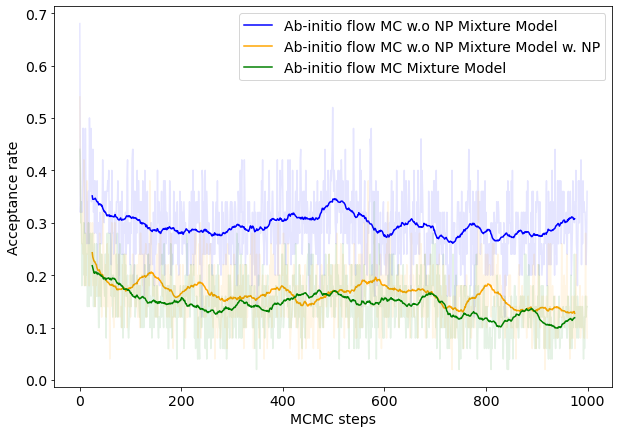

In [26]:
accs = {key: mcmcs[key]['accs'].float().mean(dim=1).detach() for key in mcmcs.keys()}

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in accs.keys():

    set_plot_sequential_data(accs[key], alpha=0.1, window_size=50, ax=ax, label=key, color=color_keys[key])
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Acceptance rate')

ax.legend()

In [27]:
accs_window = {}

for key in accs.keys():
    accs_window[key] = dict(zip(list(range(0, 4)), accs[key].reshape(4, 250).reshape(4, -1) ))

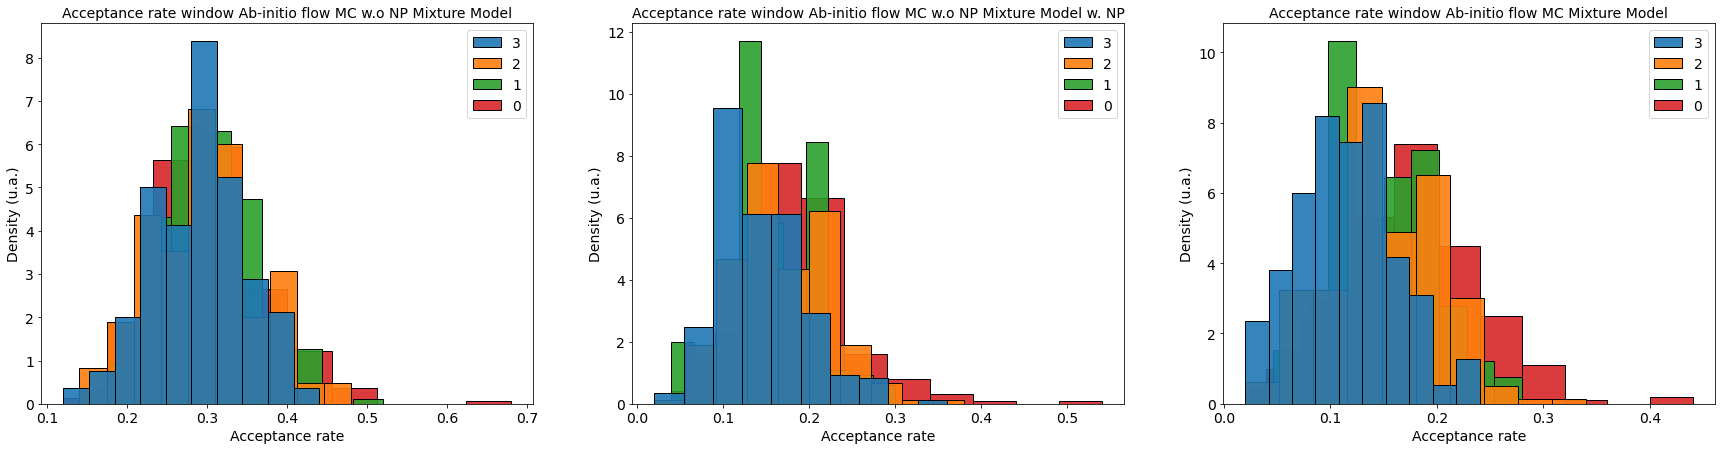

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

for i, key in enumerate(keys):
    plot_energy_histogram(accs_window[key], ax=axs[i], bins=10, alpha=0.9, hue_order=list(range(0, 4))[::-1])
    
    axs[i].set_title('Acceptance rate window {:s}'.format(key))
    axs[i].set_xlabel('Acceptance rate')

# Energy review

(-6.95, -6.4)

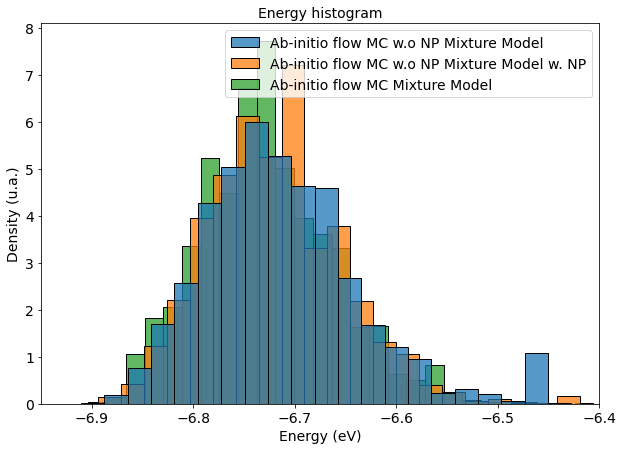

In [29]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in mcmcs.keys()}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, ax=axs, bins=30, alpha=0.75)
axs.set_title(f'Energy histogram')

axs.set_xlim(-6.95, -6.4)

# Jumps

In [43]:
def plot_jumps_along_steps(ax, isomers):

    ax.plot(isomers.detach().numpy(), '.-')
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Isomer')

In [44]:
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

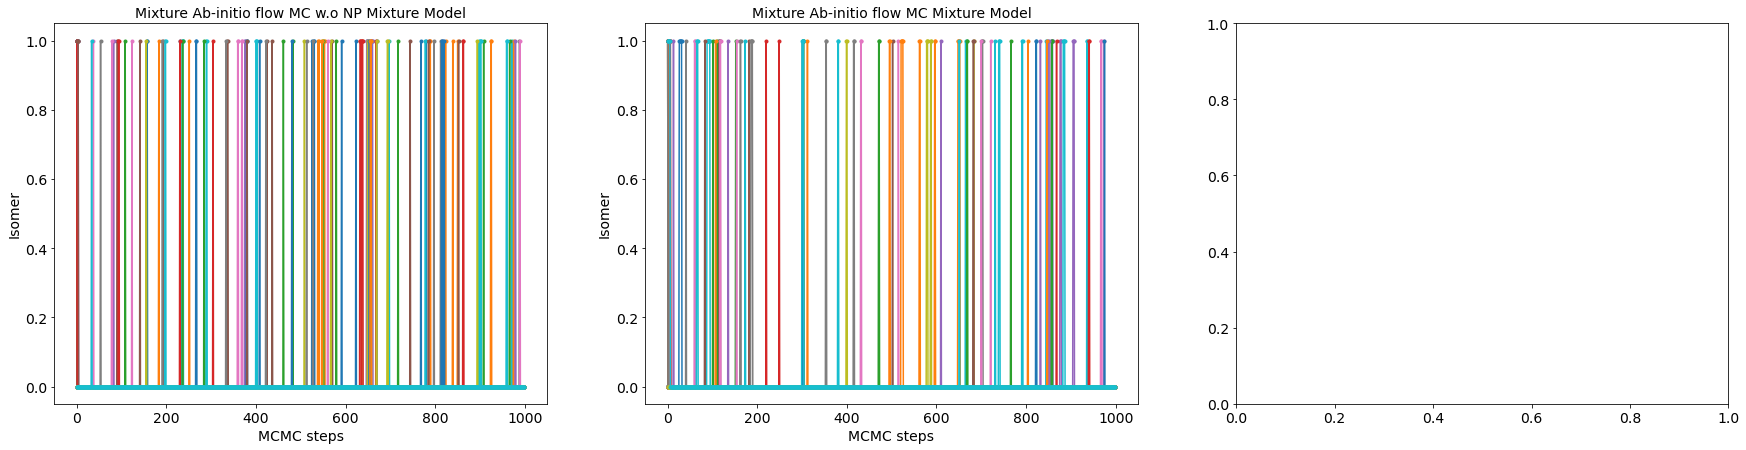

In [45]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jumps_along_steps(ax, isomers[key])

    ax.set_title('Mixture {:s}'.format(key))

In [73]:
jumps_consecutives = [len(isomers['Ab-initio flow MC w.o NP Mixture Model'][:, i].unique_consecutive(dim=0))-1 for i in range(50)]

(array([17., 14., 10.,  3.,  6.]),
 array([ 0. ,  2.4,  4.8,  7.2,  9.6, 12. ]),
 <BarContainer object of 5 artists>)

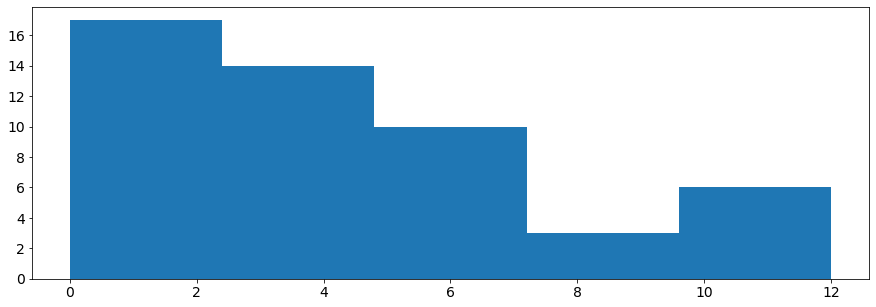

In [75]:
fig, ax = plt.
ax.hist(jumps_consecutives, bins=5)

In [34]:
from flonacomldft.utils.diagnostics import R_hat
from flonacomldft.internal_coordinates import Coordinates_mapping

In [35]:
coord_mapping = Coordinates_mapping()

In [36]:
def get_zmat_from_real(xs, isomers, etype='dft'):

    xs = xs.clone().detach().numpy().transpose(1, 0, 2)
    isomers = isomers.clone().detach().numpy().transpose(1, 0)

    coord_mapping = Coordinates_mapping(etype=etype)

    zmat = torch.zeros(xs.shape)

    for i in range(xs.shape[1]):
        for j in range(xs.shape[0]):
            zmat[j, i] = coord_mapping.get_internal_from_real_centered(torch.tensor(xs[j, i]).reshape(1, -1), 
                                                                        isomer=isomers[j, i])[0]
    zmat = zmat.clone().detach().numpy()

    return zmat

# $\hat{R} $ test

In [37]:
def plot_rhat(ax, rhat):

    ax.plot(rhat[1], rhat[0], '-o',  label=rhat[2])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')

In [38]:
xs = {key: mcmcs[key]["xs"].detach() for key in mcmcs.keys()}

In [39]:
zmats = {key: get_zmat_from_real(xs[key], isomers[key]) for key in xs.keys()}

rhat_s = {key: R_hat(zmats[key], n_split=10) for key in keys}

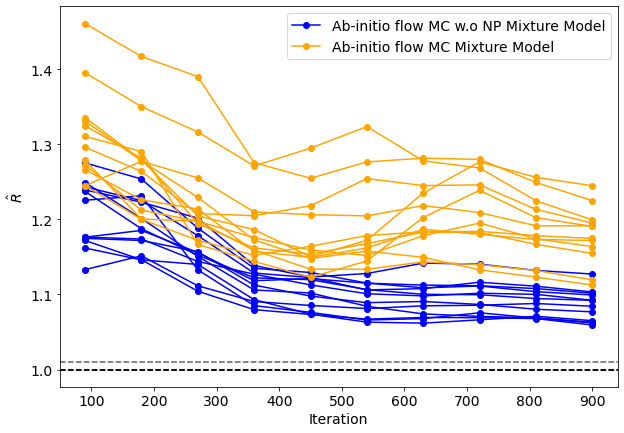

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
for key in rhat_s.keys():
    ax.plot(rhat_s[key][1], rhat_s[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

# Populations

In [113]:
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

(0.0, 0.03)

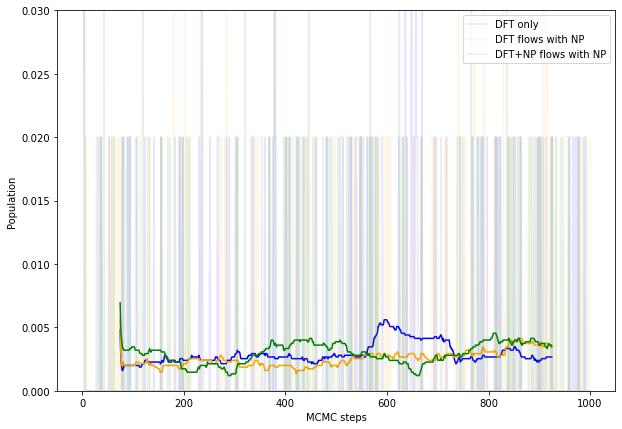

In [114]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in keys:
    set_plot_sequential_data(isomers[key].mean(dim=1).detach(), avg=True, window_size=150, ax=ax, label=key, color=color_keys[key], alpha=0.1)

ax.set_xlabel('MCMC steps')
ax.set_ylabel('Population')
ax.legend()

ax.set_ylim(0, 0.03)

In [13]:
#from flonacomldft.utils.io_utils import get_project_path
#from flonacomldft.utils.plots import plot_energy_histogram

In [14]:
#isomer = 0
#n_id = 29941690
#project_path = get_project_path()
#results_folder = project_path + '/1-adaptive/results_adaptive_is{:d}_{:d}'.format(isomer, n_id)

In [15]:
#path_xs_proposals_save = 'xs_proposals_is{:d}_{:d}.csv'.format(isomer, n_id)
#xs_proposals = pd.read_csv(results_folder+'/'+path_xs_proposals_save)
#path_xs_proposals_comp = 'is{:d}_proposals_xs_{:d}.csv'.format(isomer, n_id)
#xs_proposals_comp = pd.read_csv(results_folder+'/'+path_xs_proposals_comp)

In [16]:
#xs_proposals.shape, xs_proposals_comp.shape

In [17]:
#energies_proposals = {
#    'file': xs_proposals['potential_energy'],#[50:1050],
#    'read': xs_proposals_comp['potential_energy'],#[0:1000],
#}

In [18]:
#plot_energy_histogram(energies_proposals)